In [43]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import shap
import seaborn as sns

In [44]:
df = pd.read_csv('../data/data.csv')
df.head()

,fecha,id_producto,id_sucursal,Suma de unidades_vendidas
0,2023-01-01 00:00:00,P001,S01,56
1,2023-01-01 00:00:00,P001,S02,55
2,2023-01-01 00:00:00,P001,S03,92
3,2023-01-01 00:00:00,P001,S04,65
4,2023-01-01 00:00:00,P001,S05,66


In [45]:
# Fix columns
# Name
df = df.rename(columns={"Suma de unidades_vendidas": "ventas"})
df['ventas'] = df['ventas'].fillna(0)

# Fechas
df['fecha'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha'].dt.year

meses_num = df['fecha'].dt.month
dias_num = df['fecha'].dt.dayofweek

df['mes_sin'] = np.sin(2 * np.pi * meses_num / 12)
df['mes_cos'] = np.cos(2 * np.pi * meses_num / 12)

df['dia_sin'] = np.sin(2 * np.pi * dias_num / 7)
df['dia_cos'] = np.cos(2 * np.pi * dias_num / 7)

año_minimo = df['año'].min()
df['tendencia_anual'] = df['año'] - año_minimo

df_sorted = df.sort_values('fecha').reset_index(drop=True)

df = df.drop(columns=["fecha", "año"], errors='ignore')
df

,id_producto,id_sucursal,ventas,mes_sin,mes_cos,dia_sin,dia_cos,tendencia_anual
0,P001,S01,56,0.5,0.866025,-0.781831,0.62349,0
1,P001,S02,55,0.5,0.866025,-0.781831,0.62349,0
2,P001,S03,92,0.5,0.866025,-0.781831,0.62349,0
3,P001,S04,65,0.5,0.866025,-0.781831,0.62349,0
4,P001,S05,66,0.5,0.866025,-0.781831,0.62349,0
...,...,...,...,...,...,...,...,...
29994,P011,S02,26,-0.5,0.866025,0.781831,0.62349,0
29995,P011,S03,69,-0.5,0.866025,0.781831,0.62349,0
29996,P011,S05,33,-0.5,0.866025,0.781831,0.62349,0
29997,P012,S01,12,-0.5,0.866025,0.781831,0.62349,0


In [46]:
X_lgb_sorted = df_sorted.drop(columns=["ventas", "fecha", "año"], errors='ignore').copy()
X_lgb_sorted['id_producto'] = X_lgb_sorted['id_producto'].astype('category')
X_lgb_sorted['id_sucursal'] = X_lgb_sorted['id_sucursal'].astype('category')
y_sorted = df_sorted["ventas"]

corte = int(len(df_sorted) * 0.8)
X_train_lgb, X_test_lgb = X_lgb_sorted.iloc[:corte], X_lgb_sorted.iloc[corte:]
y_train, y_test = y_sorted.iloc[:corte], y_sorted.iloc[corte:]

lgbm_base = lgb.LGBMRegressor(objective='tweedie', random_state=521, n_jobs=-1)
param_dist = {
    'num_leaves': stats.randint(20, 100),
    'learning_rate': stats.uniform(0.01, 0.1),
    'n_estimators': stats.randint(100, 1000),
    'min_child_samples': stats.randint(10, 50),
    'tweedie_variance_power': stats.uniform(1.1, 0.8) 
}

tscv = TimeSeriesSplit(n_splits=5)

# search = RandomizedSearchCV(
#     estimator=lgbm_base,
#     param_distributions=param_dist,
#     n_iter=40, # Probará 40 combinaciones estratégicas
#     scoring='neg_mean_absolute_error',
#     cv=tscv,
#     verbose=1,
#     random_state=521,
#     n_jobs=-1
# )

lgbm = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.413334819346127,
    learning_rate=0.02864954741195319,
    min_child_samples=25,
    n_estimators=168,
    num_leaves=22,
    n_jobs=-1
)

lgbm.fit(X_train_lgb, y_train)
# print(f"\nThe absolute best parameters from your grid: {search.best_params_}")

# best_model = search.best_estimator_
y_pred = lgbm.predict(X_test_lgb)

print(f"MAE optimizado (Tweedie + TimeSplit): {mean_absolute_error(y_test, y_pred):.2f} unidades")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 23999, number of used features: 6
[LightGBM] [Info] Start training from score 3.067847
MAE optimizado (Tweedie + TimeSplit): 6.87 unidades


In [47]:
# Construir df_eval: las filas de test + su predicción + el id_producto correspondiente
df_eval = df_sorted.iloc[corte:].copy()
df_eval['pred'] = y_pred

# Clasificar cada producto por su nivel de rotación (volumen promedio de venta)
venta_promedio_producto = df_sorted.groupby('id_producto')['ventas'].mean()
df_eval['venta_promedio'] = df_eval['id_producto'].map(venta_promedio_producto)
df_eval['rotacion'] = pd.cut(
    df_eval['venta_promedio'],
    bins=[-1, 5, 15, 1000],
    labels=['baja', 'media', 'alta']
)

# MAE general (el que ya tenías)
print(f"MAE general: {mean_absolute_error(y_test, y_pred):.2f} unidades")

# MAE por nivel de rotación
mae_por_rotacion = df_eval.groupby('rotacion').apply(
    lambda g: mean_absolute_error(g['ventas'], g['pred'])
)
print("\nMAE por nivel de rotación:")
print(mae_por_rotacion)

# Bonus: MAE como % de la venta promedio de ese grupo (más fácil de explicarle a Carlos)
mae_pct = (mae_por_rotacion / df_eval.groupby('rotacion')['ventas'].mean()) * 100
print("\nMAE como % de la venta promedio:")
print(mae_pct.round(1))

MAE general: 6.87 unidades

MAE por nivel de rotación:
rotacion
baja      1.546315
media     4.231941
alta     11.732724
dtype: float64

MAE como % de la venta promedio:
rotacion
baja     43.8
media    30.7
alta     32.8
dtype: float64


C:\Users\markg\AppData\Local\Temp\ipykernel_9516\339125920.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_por_rotacion = df_eval.groupby('rotacion').apply(
C:\Users\markg\AppData\Local\Temp\ipykernel_9516\339125920.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_por_rotacion = df_eval.groupby('rotacion').apply(
C:\Users\markg\AppData\Local\Temp\ipykernel_9516\339125920.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda

In [48]:
explainer = shap.TreeExplainer(lgbm)
shap_exp = explainer(X_test_lgb)
exp = shap_exp[5051]

c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


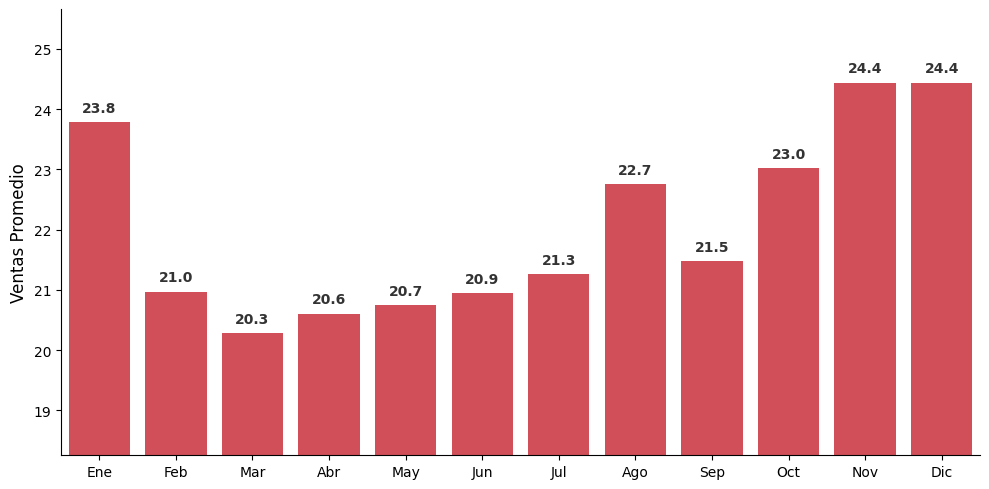

In [50]:
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

efecto_meses = []
X_simulacion = X_train_lgb.copy()

for mes in range(1, 13):
    X_simulacion['mes_sin'] = np.sin(2 * np.pi * mes / 12)
    X_simulacion['mes_cos'] = np.cos(2 * np.pi * mes / 12)
    efecto_meses.append(lgbm.predict(X_simulacion).mean())

plt.figure(figsize=(10, 5))
barras = sns.barplot(x=nombres_meses, y=efecto_meses, color='#E63946')

plt.ylabel('Ventas Promedio', fontsize=12)

max_val = max(efecto_meses)
plt.ylim(min(efecto_meses) * 0.9, max_val * 1.05)

for barra in barras.patches:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (max_val * 0.005), 
             f'{yval:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

sns.despine()
plt.tight_layout()
plt.show()
